In [6]:
# imports
from numpy import asarray, arange
from numpy.random import rand, seed
from numpy import zeros
import numpy as np
from matplotlib import pyplot as plt

# define the objective function: f(x) = x^2
def objective(x):
    return x**2.0

# derivative of f(x) = 2x
def derivative(x):
    return 2 * x

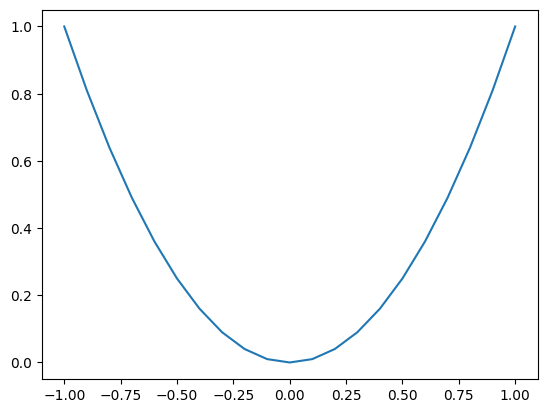

1 Iteration, [0.74724774] : [0.55837919]
2 Iteration, [0.54175461] : [0.29349806]
3 Iteration, [0.37175575] : [0.13820234]
4 Iteration, [0.24640494] : [0.0607154]
5 Iteration, [0.15951871] : [0.02544622]
6 Iteration, [0.1015491] : [0.01031222]
7 Iteration, [0.0638484] : [0.00407662]
8 Iteration, [0.03976851] : [0.00158153]
9 Iteration, [0.02459084] : [0.00060471]
10 Iteration, [0.01511937] : [0.0002286]
11 Iteration, [0.00925406] : [8.56375411e-05]
12 Iteration, [0.00564365] : [3.18507853e-05]
13 Iteration, [0.0034318] : [1.17772401e-05]
14 Iteration, [0.00208188] : [4.33423774e-06]
15 Iteration, [0.00126053] : [1.58894099e-06]
16 Iteration, [0.00076202] : [5.80674883e-07]
17 Iteration, [0.00046006] : [2.11657672e-07]
18 Iteration, [0.00027746] : [7.6985645e-08]
19 Iteration, [0.00016719] : [2.79526144e-08]
20 Iteration, [0.00010067] : [1.01345552e-08]
21 Iteration, [6.05804744e-05] : [3.66999388e-09]
22 Iteration, [3.64373635e-05] : [1.32768146e-09]
23 Iteration, [2.19069576e-05] : [4

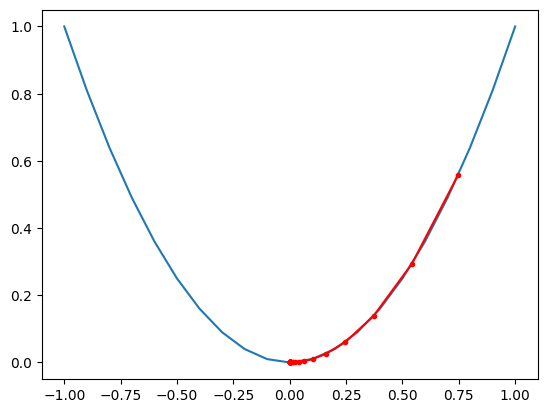

In [ ]:
# gradient descent with momentum
def gradient_descent(objective, derivative, bounds, n_iter, step_size, momentum):
    solutions, scores = list(), list()
    
    # initialize randomly inside bounds
    solution = bounds[:, 0] + rand(len(bounds)) * (bounds[:, 1] - bounds[:, 0])
    change = 0.0
    
    for i in range(n_iter):
        gradient = derivative(solution)
        
        # apply momentum 
        new_change = step_size * gradient + momentum * change 
        
        # update solution 
        solution = solution - new_change
        change = new_change
        
        # evaluate
        solution_eval = objective(solution)
        solutions.append(solution)
        scores.append(solution_eval) 
        
        print(f"{i+1} Iteration, {solution} : {solution_eval}")
    
    return solutions, scores   # <-- IMPORTANT!

# correct bounds
seed(4)
bounds = asarray([[-1.0, 1.0]])

n_iter = 30
step_size = 0.1
momentum = 0.3

inputs = arange(bounds[0,0], bounds[0,1] + 0.1, 0.1)
results = objective(inputs)
plt.plot(inputs, results)
plt.show()

solutions, scores = gradient_descent(objective, derivative, bounds, n_iter, step_size, momentum)
plt.plot(inputs, results) 
plt.plot(solutions, scores, '.-', color='red')
plt.show()


### ✅ **How to Apply Momentum Gradient Descent to a Real Dataset**

* **Replace your toy function** (e.g., (x^2)) with a **real loss function** (e.g., cross-entropy for classification, MSE for regression).
* **Use real feature data (X)** instead of a single number.
* **Use real labels (y)** and convert them if needed (e.g., one-hot for multiclass).
* **Initialize weights and bias** randomly just like before.
* **Compute predictions** using a real model:

  * linear regression → (y = XW + b)
  * logistic → sigmoid
  * multiclass → softmax
* **Compute the gradient** of the loss with respect to weights and bias.
* **Update using momentum rule:**
  [
  v = \mu v + \alpha \nabla L,\quad W = W - v
  ]
* **Repeat for many epochs** until loss decreases.
* **Check performance** using accuracy (classification) or RMSE (regression).

---

### ⭐ In one sentence:

> You replace the simple function with a real loss, compute gradients from real data, and apply the same momentum update rule to learn weights.

---

If you want, I can give **a 5-bullet version** or **a 1-sentence version** too.
